In [67]:
from collections import Counter
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from ml_product_categorizer.scripts.categorizer import find_closest_category
from ml_product_categorizer.scripts.preprocessing import (
    extract_keywords,
    flatten_categories,
    keywords_cleaner,
    slugify_categories,
)

In [68]:
products_url = pd.read_csv("../data/mlops_url_dataset.csv")

## Попробуем получить максимальную возможную информацию из ссылки на товар
1. hostname
2. ключевые слова, которые есть в ссылке

In [69]:
products_url["host"] = products_url["url"].apply(lambda x: urlparse(x).netloc)

In [70]:
products_url["keywords"] = products_url["url"].apply(extract_keywords)

In [71]:
products_url

,url,host,keywords
0,https://mnogosna.ru/tipy-matrasov/proizvoditel...,mnogosna.ru,"[tipy, matrasov, proizvoditeli, luntek, micro,..."
1,https://www.tmktools.ru/product/sverlo-po-meta...,www.tmktools.ru,"[product, sverlo, po, metallu, udlinennoe, mak..."
2,https://www.letu.ru/product/polisfera-slaider-...,www.letu.ru,"[product, polisfera, slaider, dizain, dlya, no..."
3,https://lgcity.ru/product/sumka_3778.html,lgcity.ru,"[product, sumka, html]"
4,https://www.eldorado.ru/cat/detail/elektriches...,www.eldorado.ru,"[cat, detail, elektricheskiy, dukhovoy, shkaf,..."
...,...,...,...
2995,https://mrgarage.ru/products/BMW/13717602643.html,mrgarage.ru,"[products, bmw, html]"
2996,https://shlepakov.ru/catalog/auto/tyre/nexen/n...,shlepakov.ru,"[catalog, auto, tyre, nexen, nblue, hd, plus, ..."
2997,https://ufa.bestmebelshop.ru/catalog/prikhozhi...,ufa.bestmebelshop.ru,"[catalog, prikhozhie, veshalka, vesta, bms]"
2998,https://saratov.bestmebelshop.ru/catalog/stoly...,saratov.bestmebelshop.ru,"[catalog, stoly, kompyuternye, stol, dlya, nou..."


In [72]:
products_url.describe()

,url,host,keywords
count,3000,3000,3000
unique,3000,231,2604
top,https://lu.ru/sortament/lyustri/potolochnie/po...,www.letu.ru,[item]
freq,1,67,57


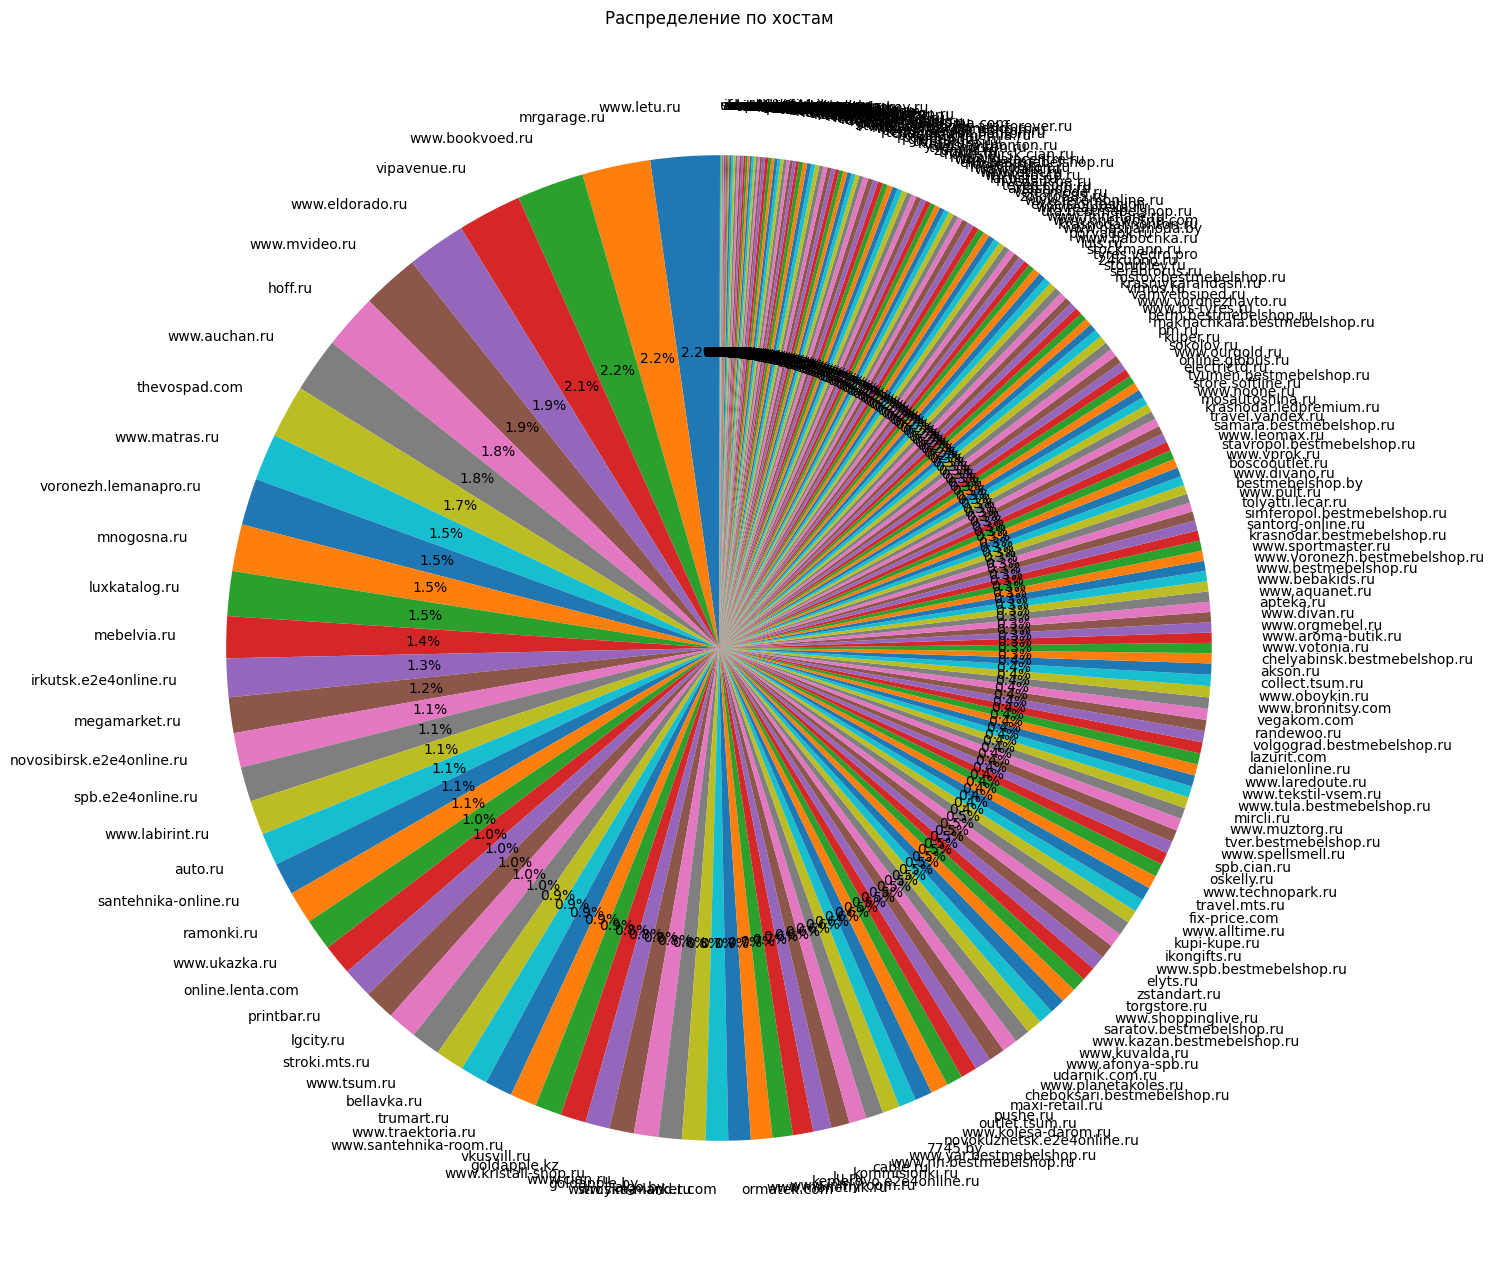

In [94]:
host_counts = products_url["host"].value_counts()

plt.figure(figsize=(16, 16))
plt.pie(host_counts, labels=host_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Распределение по хостам")
plt.savefig("../reports/figures/eda_most_common_hostnames.png")
plt.show()

Т.к. источников очень много, писать индивидуальные парсера под каждый сайт бессмысленно, как вариант нужно брать всю информацию с сайта и затем ее очищать с помощью стоп слов и регулярных выражений

Проанализируем сами слова, которые используются в ссылках

In [75]:
all_keywords = []

for host_keywords in products_url["keywords"].tolist():
    all_keywords += host_keywords

In [76]:
keywords_counter_top_20 = dict(Counter(all_keywords).most_common(20))

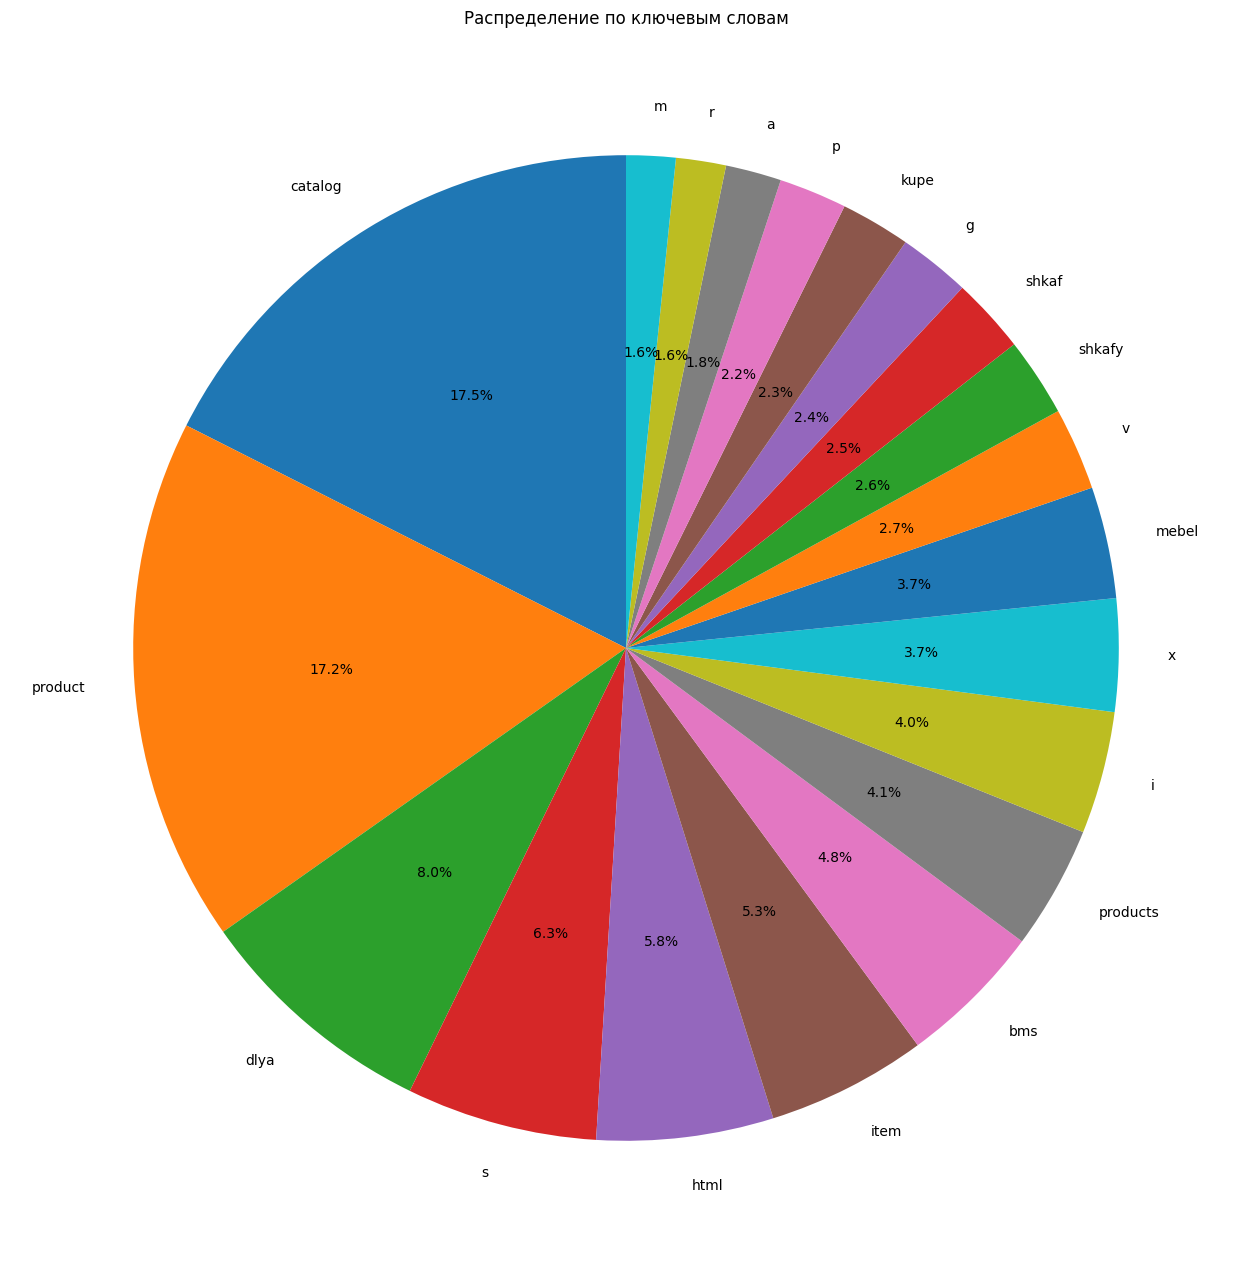

In [95]:
plt.figure(figsize=(16, 16))
plt.pie(
    keywords_counter_top_20.values(),
    labels=keywords_counter_top_20.keys(),
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Распределение по ключевым словам")
plt.savefig("../reports/figures/eda_most_common_keywords.png")
plt.show()

Этот график показывает наиболее употребляемые слова, но по факту это шумовые данные, которые не несут в себе никакой информации. Поэтому нужно сделать очистку списка ключевых слов, удалив 
- одиночные буквы
- числа
- удалить слова 'catalog', 'item', 'product', 'products', 'cat', 'dlya', 'katalog'

In [78]:
products_url["cleaned_keywords"] = products_url["keywords"].apply(keywords_cleaner)

Все данные из url вытащены и почищены, теперь можно поработать с категориями, для этого их нужно прочитать из файла, получив список категорий, после этого приведем строки lower и получим slug от них, после чего уберем - и попробуем вычислить ближайшую категорию для каждого урла, получив эмбедининги и посчитав косинусное расстояние 

In [79]:
import json

In [80]:
with open("../data/ru_ecomm_tree_category.json", encoding="utf-8") as file:
    data_categories = json.load(file)

In [82]:
categories_list = flatten_categories(data_categories)

In [83]:
categories_list[::10]

['красота и уход уход за лицом',
 'хобби и увлечения моделизм',
 'здоровье витамины и бады',
 'детские товары детское питание',
 'строительство и ремонт сварочное оборудование',
 'строительство и ремонт лакокрасочные материалы',
 'ювелирные изделия и часы колье',
 'сад и огород мебель для сада',
 'зоотовары ветеринарные услуги',
 'цветы и подарки цветы',
 'мебель мебель для геймеров',
 'транспорт автотовары и запчасти тюнинг и аксессуары для авто',
 'одежда, обувь и аксессуары женская одежда плащи и тренчи',
 'одежда, обувь и аксессуары женская одежда костюмы',
 'одежда, обувь и аксессуары мужская одежда утепленные жилетки',
 'одежда, обувь и аксессуары мужская одежда рубашки',
 'одежда, обувь и аксессуары женская обувь домашние тапочки',
 'одежда, обувь и аксессуары мужская обувь туфли',
 'одежда, обувь и аксессуары спортивная одежда и обувь',
 'товары для дома растения, цветы, аксессуары',
 'спорт и активный отдых спортивное питание',
 'спорт и активный отдых бокс и боевые искусства'

In [84]:
clear_slug_categories = slugify_categories(categories_list)

In [85]:
print("Общее количество категорий, с учетом подкатегорий: ", len(clear_slug_categories))

Общее количество категорий, с учетом подкатегорий:  250


In [86]:
products_url["closest_category"] = products_url["keywords"].apply(
    lambda x: find_closest_category(x, clear_slug_categories)
)

In [87]:
products_url

,url,host,keywords,cleaned_keywords,closest_category
0,https://mnogosna.ru/tipy-matrasov/proizvoditel...,mnogosna.ru,"[tipy, matrasov, proizvoditeli, luntek, micro,...","[tipy, matrasov, proizvoditeli, luntek, micro,...",None
1,https://www.tmktools.ru/product/sverlo-po-meta...,www.tmktools.ru,"[product, sverlo, po, metallu, udlinennoe, mak...","[sverlo, metallu, udlinennoe, makita, hss]",None
2,https://www.letu.ru/product/polisfera-slaider-...,www.letu.ru,"[product, polisfera, slaider, dizain, dlya, no...","[polisfera, slaider, dizain, nogtei, neonovyi,...",None
3,https://lgcity.ru/product/sumka_3778.html,lgcity.ru,"[product, sumka, html]",[sumka],None
4,https://www.eldorado.ru/cat/detail/elektriches...,www.eldorado.ru,"[cat, detail, elektricheskiy, dukhovoy, shkaf,...","[detail, elektricheskiy, dukhovoy, shkaf, smeg...",None
...,...,...,...,...,...
2995,https://mrgarage.ru/products/BMW/13717602643.html,mrgarage.ru,"[products, bmw, html]",[bmw],None
2996,https://shlepakov.ru/catalog/auto/tyre/nexen/n...,shlepakov.ru,"[catalog, auto, tyre, nexen, nblue, hd, plus, ...","[auto, tyre, nexen, nblue, plus]",None
2997,https://ufa.bestmebelshop.ru/catalog/prikhozhi...,ufa.bestmebelshop.ru,"[catalog, prikhozhie, veshalka, vesta, bms]","[prikhozhie, veshalka, vesta, bms]",None
2998,https://saratov.bestmebelshop.ru/catalog/stoly...,saratov.bestmebelshop.ru,"[catalog, stoly, kompyuternye, stol, dlya, nou...","[stoly, kompyuternye, stol, noutbuka, absolyut...","[mebel, stoly, stulia]"


In [88]:
products_url.describe()

,url,host,keywords,cleaned_keywords,closest_category
count,3000,3000,3000,3000,651
unique,3000,231,2604,2571,98
top,https://lu.ru/sortament/lyustri/potolochnie/po...,www.letu.ru,[item],[],"[mebel, miagkaia, mebel]"
freq,1,67,57,189,111


In [89]:
products_url.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   url               3000 non-null   object
 1   host              3000 non-null   object
 2   keywords          3000 non-null   object
 3   cleaned_keywords  3000 non-null   object
 4   closest_category  651 non-null    object
dtypes: object(5)
memory usage: 117.3+ KB


## Дальнейшие шаги + выводы по EDA
На данный момент получилось только по url категоризировать 651 товар путем извлечения информации из ссылок, конвертирование исходных категорий в slug формат и сравнение их как множества через iou.

### Гипотеза 1. Продолжать развивать данный подход
- Попробовать сделать обратный к slug процесс, для получениях исходных названий товаров, стемминг для полученных данных и категорий и повторное сравнение по iou
- Получить эмбединги с помощью tf-idf и сравнить вектора с помощью косинусной близости

### Гипотеза 2. Попробовать все-таки обкачать данные
Подход не совсем правильный, т.к. непонятно сколько есть времени на категоризацию товара, т.к. есть временные затраты на получения страницы + ее дальнейшая обработка
- Попробовать по ссылкам из датасета получить текст страницы, произвести предобработку и попробовать полученный текст сравнить по косинусной близости 


### Гипотеза 3. Комбинированный подход по url и тексту продукта
Если не удалось получить информацию по url, то категоризаци по url, учет и url и информации с сайта, информация с сайта, если информации из url недостаточно или не остается ключевых слов после обработки